In [ ]:
# ============================================================
# Heart Disease Prediction using Logistic Regression (No machine learning library)
# ------------------------------------------------------------
# Name      : Haris Farooq
# Reg No    : 2024395
# Course No : AI221L
# Task No   : 1
# ------------------------------------------------------------

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv('heart.csv')
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())
df.head()


Dataset Shape: (1025, 14)

Data Types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Null Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Summary Statistics:
                age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.0000

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


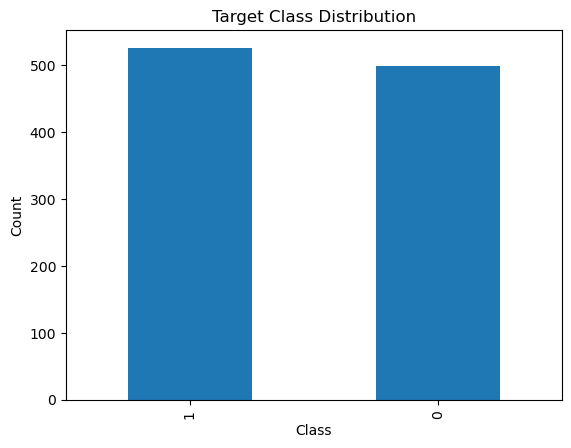

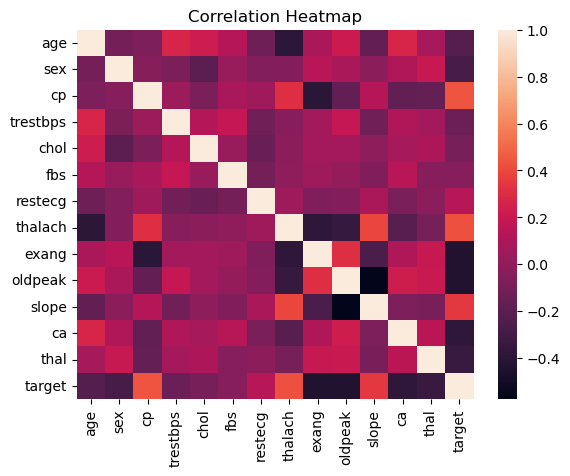

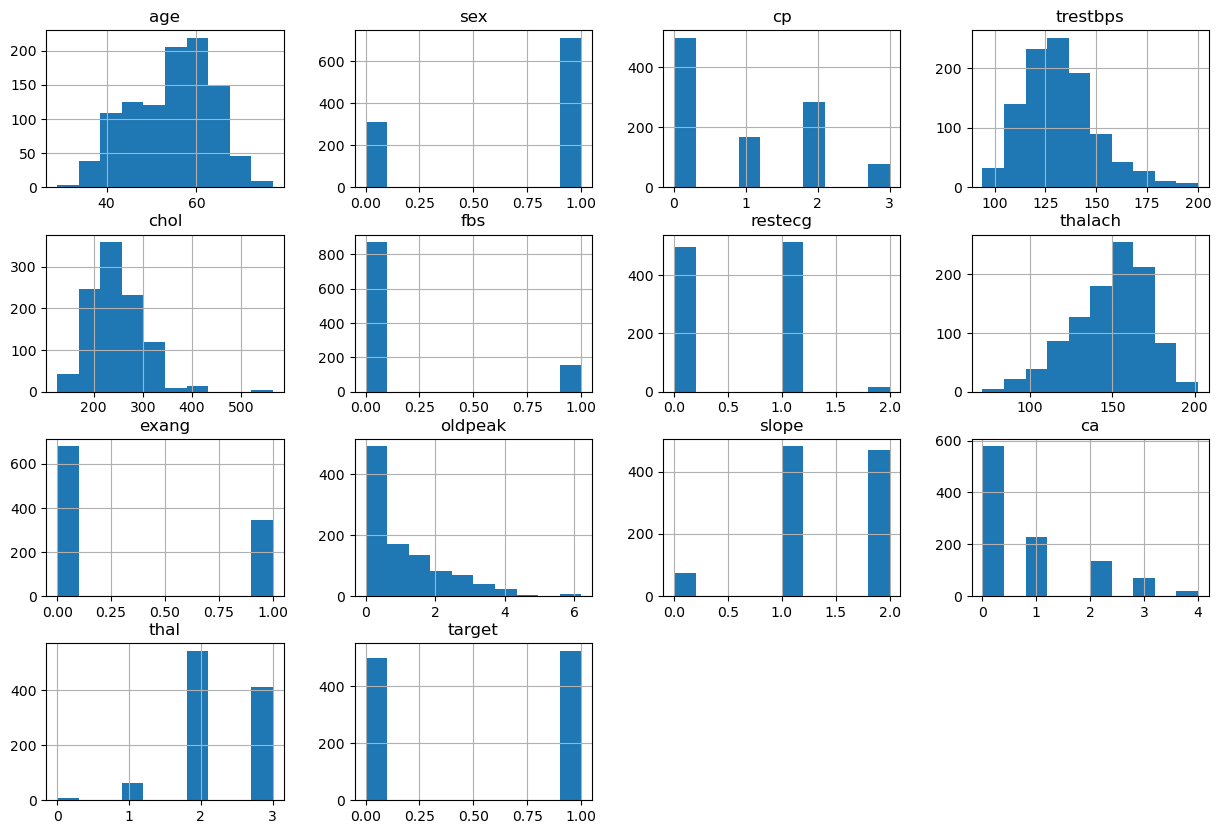

In [ ]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

df.hist(figsize=(15,10))
plt.show()


In [ ]:
df.fillna(df.mean(), inplace=True) #dealing with the null values


In [ ]:
X = df.drop('target', axis=1).values
y = df['target'].values

mean = np.mean(X, axis=0)   # performed the Z score normalisation
std = np.std(X, axis=0)
X = (X - mean) / std


In [38]:
split_ratio = 0.8 #80-20 train test split 
index = int(len(X) * split_ratio)

X_train = X[:index]
X_test = X[index:]
y_train = y[:index]
y_test = y[index:]


In [25]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [27]:
def compute_loss(y, y_hat):
    m = len(y)
    epsilon = 1e-9  
    loss = -(1/m) * np.sum(
        y * np.log(y_hat + epsilon) +
        (1 - y) * np.log(1 - y_hat + epsilon)
    )
    return loss


In [32]:
def train_logistic_regression(X, y, lr=0.01, iterations=1000):
    m, n = X.shape
    
    weights = np.zeros(n)
    bias = 0
    
    for i in range(iterations):
        linear_model = np.dot(X, weights) + bias
        y_hat = sigmoid(linear_model)
        
        
        dw = (1/m) * np.dot(X.T, (y_hat - y))   #gradients calculation
        db = (1/m) * np.sum(y_hat - y)
        
        # update
        weights -= lr * dw
        bias -= lr * db
        
        if i % 250 == 0:
            print(f"Iteration {i}, Loss: {compute_loss(y, y_hat)}")
    
    return weights, bias


In [33]:
weights, bias = train_logistic_regression(X_train, y_train, lr=0.01, iterations=2000)


Iteration 0, Loss: 0.6931471785599453
Iteration 250, Loss: 0.40963824940883137
Iteration 500, Loss: 0.3661289671005486
Iteration 750, Loss: 0.34992611457207656
Iteration 1000, Loss: 0.34181853113007465
Iteration 1250, Loss: 0.3371382454974136
Iteration 1500, Loss: 0.3342008951242049
Iteration 1750, Loss: 0.33225438269635704


In [40]:
def train_logistic_l2(X, y, lr=0.01, iterations=1000, lambda_=1):
    m, n = X.shape
    
    weights = np.zeros(n)
    bias = 0
    
    for i in range(iterations):
        linear_model = np.dot(X, weights) + bias
        y_hat = sigmoid(linear_model)
        
        
        dw = (1/m) * np.dot(X.T, (y_hat - y)) + (lambda_/m) * weights #new graidents with regularization
        db = (1/m) * np.sum(y_hat - y)
        
        weights -= lr * dw
        bias -= lr * db
        
        if i % 250 == 0:
            print(f"Iteration {i}, Loss: {compute_loss(y, y_hat)}")
    
    return weights, bias


In [41]:
weights_l2_1, bias_l2_1 = train_logistic_l2(X_train, y_train, lr=0.01, iterations=2000, lambda_=1)


Iteration 0, Loss: 0.6931471785599453
Iteration 250, Loss: 0.4098202578136468
Iteration 500, Loss: 0.36639980269119116
Iteration 750, Loss: 0.3502401275652794
Iteration 1000, Loss: 0.34215337111568583
Iteration 1250, Loss: 0.3374806940863678
Iteration 1500, Loss: 0.3345424884778858
Iteration 1750, Loss: 0.33258952903125577


In [42]:
weights_l2_10, bias_l2_10 = train_logistic_l2(X_train, y_train, lr=0.01, iterations=2000, lambda_=10)


Iteration 0, Loss: 0.6931471785599453
Iteration 250, Loss: 0.4114567777024375
Iteration 500, Loss: 0.3688526723213767
Iteration 750, Loss: 0.3531203934142724
Iteration 1000, Loss: 0.34527936928042224
Iteration 1250, Loss: 0.3407500021709128
Iteration 1500, Loss: 0.3378925005303479
Iteration 1750, Loss: 0.3359806396156147


In [ ]:
# Effect of Regularization

# Training Accuracy
# - Slightly decreases with regularization
# - Prevents model from memorizing training data
# - Large lambda causes bigger drop in training accuracy

# Testing Accuracy
# - Often improves with moderate regularization
# - Reduces overfitting
# - Very large lambda may reduce testing accuracy (underfitting)

# Model Generalization
# - Controls model complexity
# - Reduces variance
# - Improves performance on unseen data
# - Too much regularization increases bias

In [43]:
#the underfitting experiment
subset_features = ['age', 'chol', 'thalach'] # subset of age , chol , thalach
X_subset = df[subset_features].values
newindex = int(len(X_subset) * split_ratio)

mean_sub = np.mean(X_subset, axis=0) 
std_sub = np.std(X_subset, axis=0)
X_subset = (X_subset - mean_sub) / std_sub #subset normalisation

X_train_sub = X_subset[:newindex]
X_test_sub = X_subset[newindex:] #train test split

weights_sub, bias_sub = train_logistic_regression(X_train_sub, y_train)


Iteration 0, Loss: 0.6931471785599453
Iteration 250, Loss: 0.6127834391240579
Iteration 500, Loss: 0.5932274705453924
Iteration 750, Loss: 0.5864226630507965


In [44]:
def predict(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    y_hat = sigmoid(linear_model)
    return (y_hat >= 0.5).astype(int)


In [50]:
from sklearn.metrics import roc_auc_score

def evaluate_full_model(X, y_true, weights, bias):
    
    linear_model = np.dot(X, weights) + bias
    y_probs = sigmoid(linear_model)
    
    y_pred = (y_probs >= 0.5).astype(int)
   
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
   
    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
    roc_auc = roc_auc_score(y_true, y_probs)
    
    return accuracy, precision, recall, f1, roc_auc


In [51]:
acc_simple, prec_simple, rec_simple, f1_simple, roc_simple = \
    evaluate_full_model(X_test, y_test, weights, bias)

print("=== Simple Logistic Regression ===")
print("Accuracy:", acc_simple)
print("Precision:", prec_simple)
print("Recall:", rec_simple)
print("F1 Score:", f1_simple)
print("ROC-AUC:", roc_simple)


=== Simple Logistic Regression ===
Accuracy: 0.7951219512195122
Precision: 0.7567567567499391
Recall: 0.8484848484762779
F1 Score: 0.7999999994940137
ROC-AUC: 0.8803125595578426


In [53]:
acc_l2_1, prec_l2_1, rec_l2_1, f1_l2_1, roc_l2_1 = \
    evaluate_full_model(X_test, y_test, weights_l2_1, bias_l2_1)

print("\n=== L2 Regularized Model (λ = 1) ===")
print("Accuracy:", acc_l2_1)
print("Precision:", prec_l2_1)
print("Recall:", rec_l2_1)
print("F1 Score:", f1_l2_1)
print("ROC-AUC:", roc_l2_1)


=== L2 Regularized Model (λ = 1) ===
Accuracy: 0.7951219512195122
Precision: 0.7567567567499391
Recall: 0.8484848484762779
F1 Score: 0.7999999994940137
ROC-AUC: 0.8805031446540881


In [54]:
acc_l2_10, prec_l2_10, rec_l2_10, f1_l2_10, roc_l2_10 = \
    evaluate_full_model(X_test, y_test, weights_l2_10, bias_l2_10)

print("\n=== L2 Regularized Model (λ = 10) ===")
print("Accuracy:", acc_l2_10)
print("Precision:", prec_l2_10)
print("Recall:", rec_l2_10)
print("F1 Score:", f1_l2_10)
print("ROC-AUC:", roc_l2_10)


=== L2 Regularized Model (λ = 10) ===
Accuracy: 0.7902439024390244
Precision: 0.7499999999933036
Recall: 0.8484848484762779
F1 Score: 0.7962085303000381
ROC-AUC: 0.8793596340766153


In [ ]:
acc_sub, prec_sub, rec_sub, f1_sub, roc_sub = \
    evaluate_full_model(X_test_sub, y_test, weights_sub, bias_sub)

print("\n=== Subset Feature Model (Underfitting Test) ===")
print("Accuracy:", acc_sub)
print("Precision:", prec_sub)
print("Recall:", rec_sub)
print("F1 Score:", f1_sub)
print("ROC-AUC:", roc_sub)




=== Subset Feature Model (Underfitting Test) ===
Accuracy: 0.6487804878048781
Precision: 0.6153846153793556
Recall: 0.7272727272653811
F1 Score: 0.666666666163966
ROC-AUC: 0.7315608919382505


In [ ]:
# Signs of Underfitting
#   as we can see above 
# - Low training accuracy
# - Low testing accuracy
# - Model fails to capture data patterns